# Activity 2: Analyzing Different Scenarios and Generating the Appropriate Visualization

We'll be working with the 120 years of Olympic History dataset acquired by Randi Griffin from https://www.sports-reference.com/ and made available on the GitHub repository of this book. Your assignment is to identify the top five sports based on the largest number of medals awarded in the year 2016, and then perform the following analysis:

1. Generate a plot indicating the number of medals awarded in each of the top five sports in 2016.
2. Plot a graph depicting the distribution of the age of medal winners in the top five sports in 2016.
3. Find out which national teams won the largest number of medals in the top five sports in 2016.
4. Observe the trend in the average weight of male and female athletes winning in the top five sports in 2016.

## Completed solution
The cells below:
- load the Olympic dataset,
- filter medal winners from 2016,
- identify the top 5 sports by medal count,
- build the required visualizations,
- and print short summaries to support the charts.


Dataset shape: (271116, 15)


,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


Rows for medal winners in 2016: 2023
Top 5 sports in 2016 by medal count:
Sport
Athletics    192
Swimming     191
Rowing       144
Football     106
Hockey        99
Name: count, dtype: int64


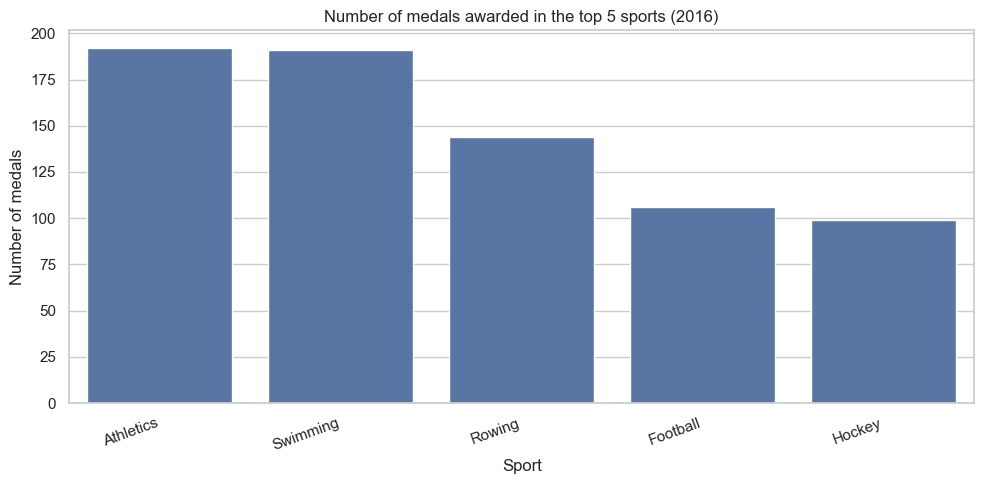

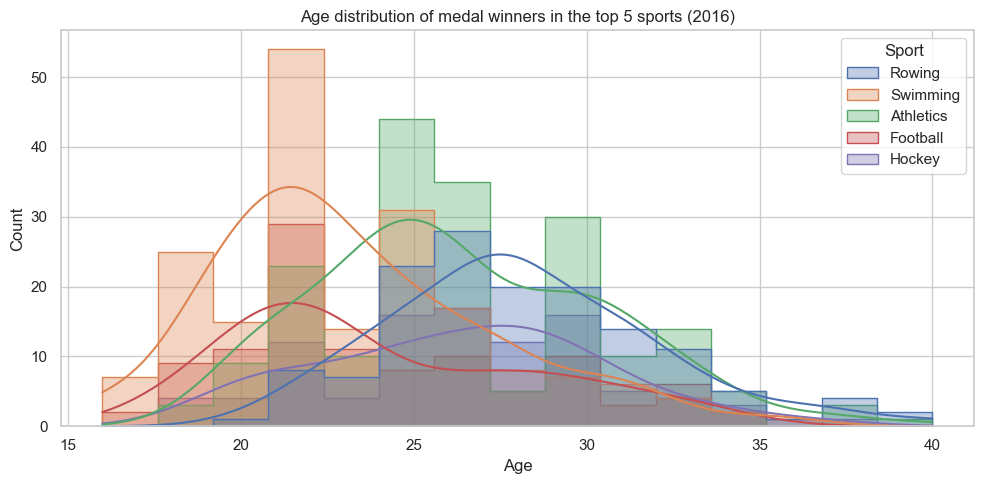

Age summary by sport:


,count,mean,median,min,max
Sport,,,,,
Athletics,192,26.411458,26.0,19.0,40.0
Swimming,191,23.230366,22.0,16.0,36.0
Rowing,144,28.125000,28.0,20.0,40.0
Football,106,24.084906,23.0,17.0,34.0
Hockey,99,26.383838,27.0,19.0,37.0


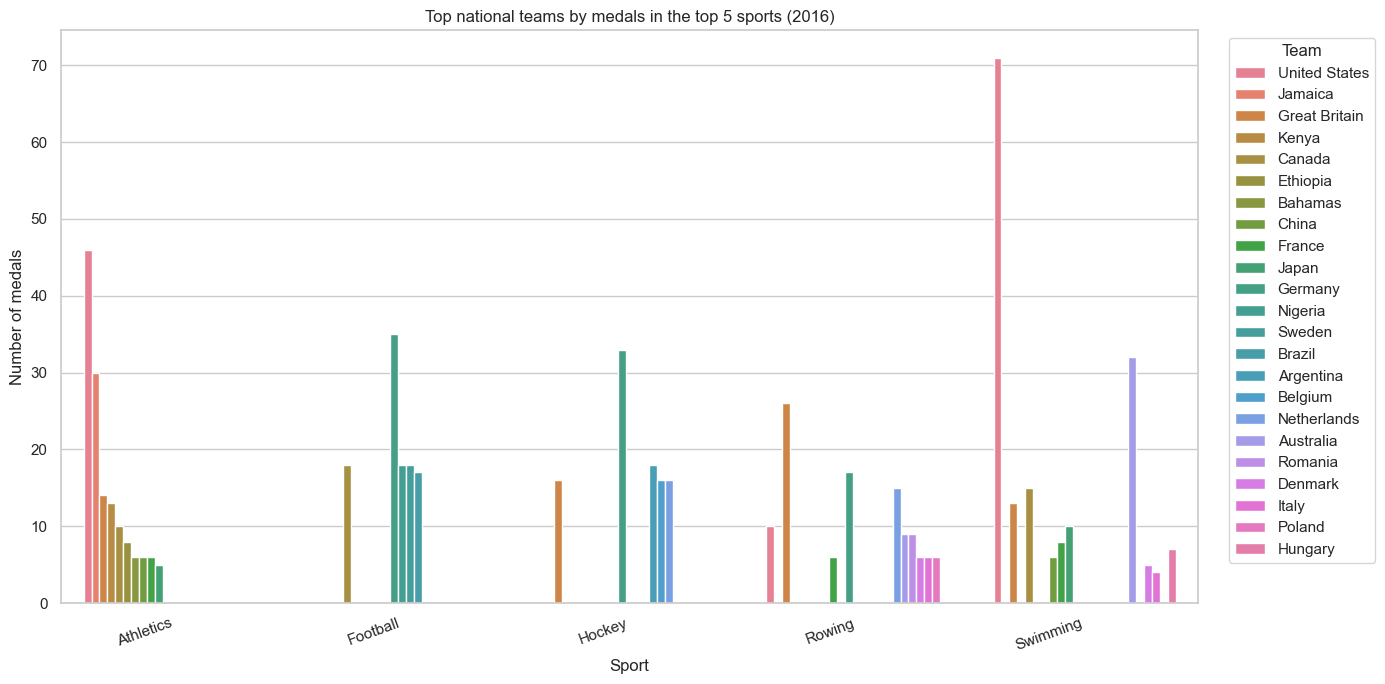

Top teams per sport:


,Sport,Team,Medal_Count
40,Athletics,United States,46
23,Athletics,Jamaica,30
19,Athletics,Great Britain,14
26,Athletics,Kenya,13
9,Athletics,Canada,10
16,Athletics,Ethiopia,8
2,Athletics,Bahamas,6
10,Athletics,China,6
17,Athletics,France,6
24,Athletics,Japan,5


Overall top teams across the top 5 sports:


,Team,Medal_Count
0,United States,127
1,Germany,88
2,Great Britain,69
3,Canada,45
4,Australia,43
5,Netherlands,34
6,Jamaica,30
7,Sweden,21
8,France,20
9,Brazil,19


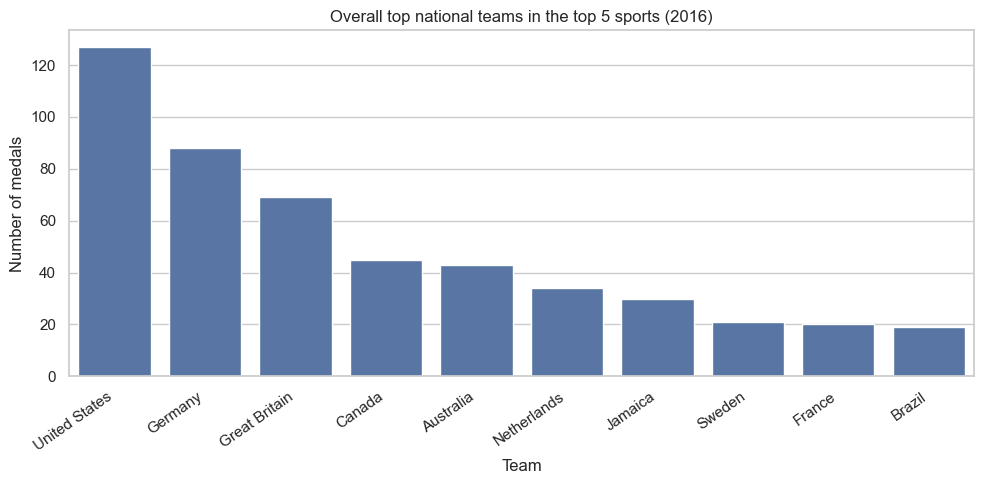

Average weight by sport and gender:


,Sport,Sex,Weight
0,Athletics,F,62.578947
1,Athletics,M,79.074468
2,Football,F,62.962963
3,Football,M,75.725490
4,Hockey,F,63.061224
5,Hockey,M,78.380000
6,Rowing,F,71.766667
7,Rowing,M,88.833333
8,Swimming,F,66.195876
9,Swimming,M,83.408602


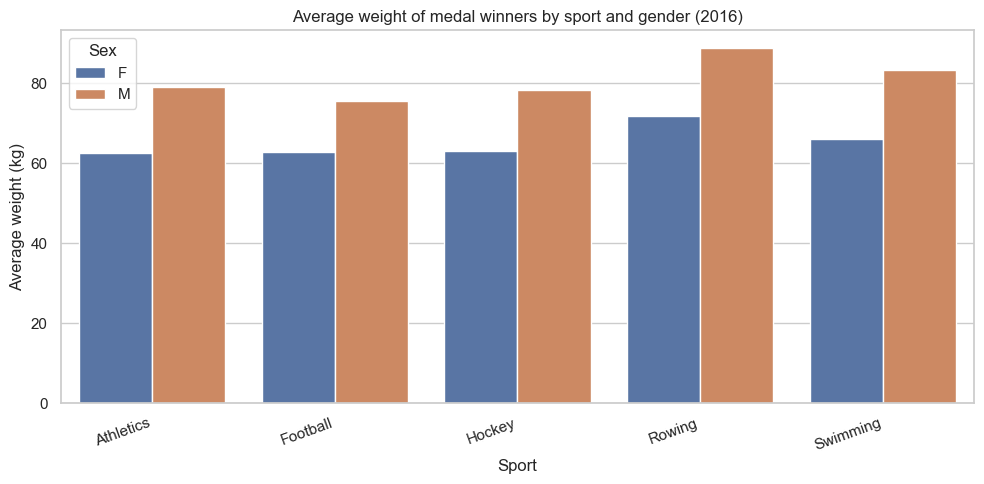


Short interpretation:
- The bar plot shows which sports generated the most medal-winning records in 2016.
- The age histogram highlights the age ranges of medal winners across the top sports.
- The team analysis shows which countries dominated these sports.
- The final chart compares the average weight of male and female medal winners by sport.


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

# Load the dataset
url = "https://raw.githubusercontent.com/TrainingByPackt/Interactive-Data-Visualization-with-Python/master/datasets/athlete_events.csv"
athletes_df = pd.read_csv(url)

print("Dataset shape:", athletes_df.shape)
display(athletes_df.head())

# Keep only medal winners in 2016
medals_2016 = athletes_df[(athletes_df["Year"] == 2016) & (athletes_df["Medal"].notna())].copy()

print("Rows for medal winners in 2016:", medals_2016.shape[0])

# Find the top 5 sports by number of medals awarded
sport_counts = (
    medals_2016["Sport"]
    .value_counts()
    .sort_values(ascending=False)
)

top5_sports = sport_counts.head(5).index.tolist()
print("Top 5 sports in 2016 by medal count:")
print(sport_counts.head(5))

top5_df = medals_2016[medals_2016["Sport"].isin(top5_sports)].copy()

# -------------------------------------------------------------------
# 1) Bar plot: number of medals awarded in each of the top five sports
# -------------------------------------------------------------------
plt.figure(figsize=(10, 5))
ax = sns.countplot(
    data=top5_df,
    x="Sport",
    order=sport_counts.head(5).index
)
ax.set_title("Number of medals awarded in the top 5 sports (2016)")
ax.set_xlabel("Sport")
ax.set_ylabel("Number of medals")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------
# 2) Distribution of the age of medal winners in the top five sports
# -------------------------------------------------------------------
plt.figure(figsize=(10, 5))
sns.histplot(
    data=top5_df,
    x="Age",
    hue="Sport",
    bins=15,
    kde=True,
    element="step",
    alpha=0.35
)
plt.title("Age distribution of medal winners in the top 5 sports (2016)")
plt.xlabel("Age")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Optional numerical summary for age
age_summary = (
    top5_df.groupby("Sport")["Age"]
    .agg(["count", "mean", "median", "min", "max"])
    .sort_values("count", ascending=False)
)
print("Age summary by sport:")
display(age_summary)

# -------------------------------------------------------------------
# 3) National teams with the largest number of medals
# -------------------------------------------------------------------
team_medals = (
    top5_df.groupby(["Sport", "Team"])
    .size()
    .reset_index(name="Medal_Count")
    .sort_values(["Sport", "Medal_Count"], ascending=[True, False])
)

top_teams_per_sport = team_medals.groupby("Sport").head(10)

plt.figure(figsize=(14, 7))
ax = sns.barplot(
    data=top_teams_per_sport,
    x="Sport",
    y="Medal_Count",
    hue="Team"
)
ax.set_title("Top national teams by medals in the top 5 sports (2016)")
ax.set_xlabel("Sport")
ax.set_ylabel("Number of medals")
plt.xticks(rotation=20, ha="right")
plt.legend(title="Team", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

print("Top teams per sport:")
display(top_teams_per_sport)

# Also show the overall top national teams across the top 5 sports
overall_top_teams = (
    top5_df["Team"]
    .value_counts()
    .head(10)
    .rename_axis("Team")
    .reset_index(name="Medal_Count")
)
print("Overall top teams across the top 5 sports:")
display(overall_top_teams)

plt.figure(figsize=(10, 5))
sns.barplot(data=overall_top_teams, x="Team", y="Medal_Count")
plt.title("Overall top national teams in the top 5 sports (2016)")
plt.xlabel("Team")
plt.ylabel("Number of medals")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------
# 4) Trend in average weight of male and female athletes
# -------------------------------------------------------------------
weight_gender = (
    top5_df.dropna(subset=["Weight"])
    .groupby(["Sport", "Sex"])["Weight"]
    .mean()
    .reset_index()
    .sort_values(["Sport", "Sex"])
)

print("Average weight by sport and gender:")
display(weight_gender)

plt.figure(figsize=(10, 5))
sns.barplot(data=weight_gender, x="Sport", y="Weight", hue="Sex")
plt.title("Average weight of medal winners by sport and gender (2016)")
plt.xlabel("Sport")
plt.ylabel("Average weight (kg)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

# Short interpretation
print("\nShort interpretation:")
print("- The bar plot shows which sports generated the most medal-winning records in 2016.")
print("- The age histogram highlights the age ranges of medal winners across the top sports.")
print("- The team analysis shows which countries dominated these sports.")
print("- The final chart compares the average weight of male and female medal winners by sport.")
